# TODO - Taxi Anomalies Dataset Analysis

In [1]:
# Import necessary libraries
import pandas as pd
import stumpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from matplotlib.patches import Rectangle
import datetime as dt
import math

plt.style.use('https://raw.githubusercontent.com/TDAmeritrade/stumpy/main/docs/stumpy.mplstyle')

# Initial Time Series Examples

In [2]:
# Time series with length n = 13
time_series = [0, 1, 3, 2, 9, 1, 14, 15, 1, 2, 2, 10, 7]
n = len(time_series)  # length of the time series
print(f"Length of time series: {n}")

Length of time series: 13


In [3]:
# Print subsequences
print(time_series[0:4])
print(time_series[4:7])

[0, 1, 3, 2]
[9, 1, 14]


In [4]:
# Extract subsequences with m=4
m = 4
i = 0  # starting index for the first subsequence
j = 8  # starting index for the second subsequence

subseq_1 = time_series[i:i+m]
subseq_2 = time_series[j:j+m]

print(subseq_1, subseq_2)

[0, 1, 3, 2] [1, 2, 2, 10]


In [5]:
# Calculate Euclidean distance
import math

D = 0
for k in range(m):
    D += (subseq_1[k] - subseq_2[k])**2
print(f"The square root of {D} = {math.sqrt(D)}")

The square root of 67 = 8.18535277187245


In [6]:
# Brute force approach for distance matrix
for i in range(n-m+1):
    for j in range(n-m+1):
        D = 0
        for k in range(m):
            D += (time_series[i+k] - time_series[j+k])**2
        D = math.sqrt(D)

# Example 1: Steamgen Dataset

In [8]:
# Read the Steamgen data
steam_df = pd.read_csv('steamgen_anomalies.csv')  # Assuming the file exists
steam_df

,drum pressure,excess oxygen,water level,steam flow
0,320.08239,2.506774,0.032701,9.302970
1,321.71099,2.545908,0.284799,9.662621
2,320.91331,2.360562,0.203652,10.990955
3,325.00252,0.027054,0.326187,12.430107
4,326.65276,0.285649,0.753776,13.681666
...,...,...,...,...
9595,247.41260,0.022345,-1.993993,7.898815
9596,245.71311,1.483497,-2.124374,7.729076
9597,247.18731,0.016897,-1.606152,7.856854
9598,247.95637,0.477808,-1.813088,7.799764


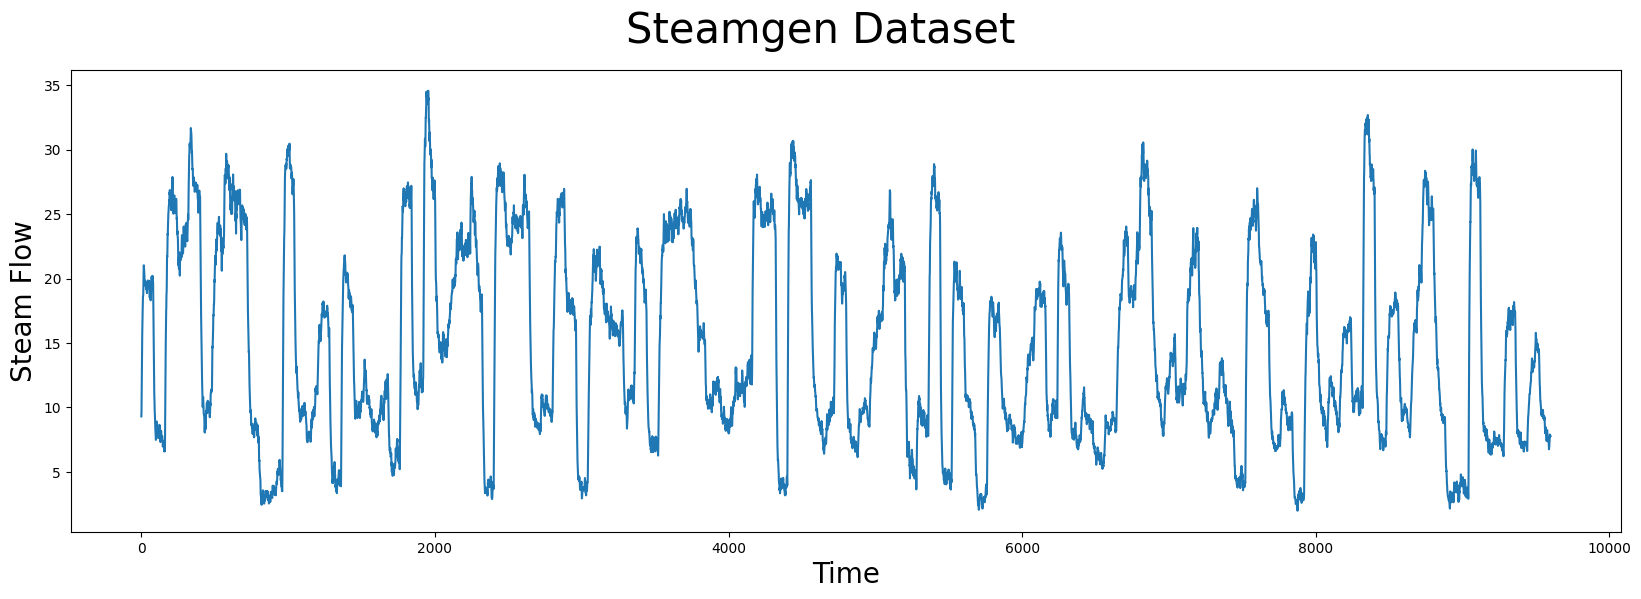

In [9]:
# Visualize Steamgen dataset
plt.suptitle('Steamgen Dataset', fontsize='30')
plt.xlabel('Time', fontsize='20')
plt.ylabel('Steam Flow', fontsize='20')
plt.plot(steam_df['steam flow'].values)
plt.show()

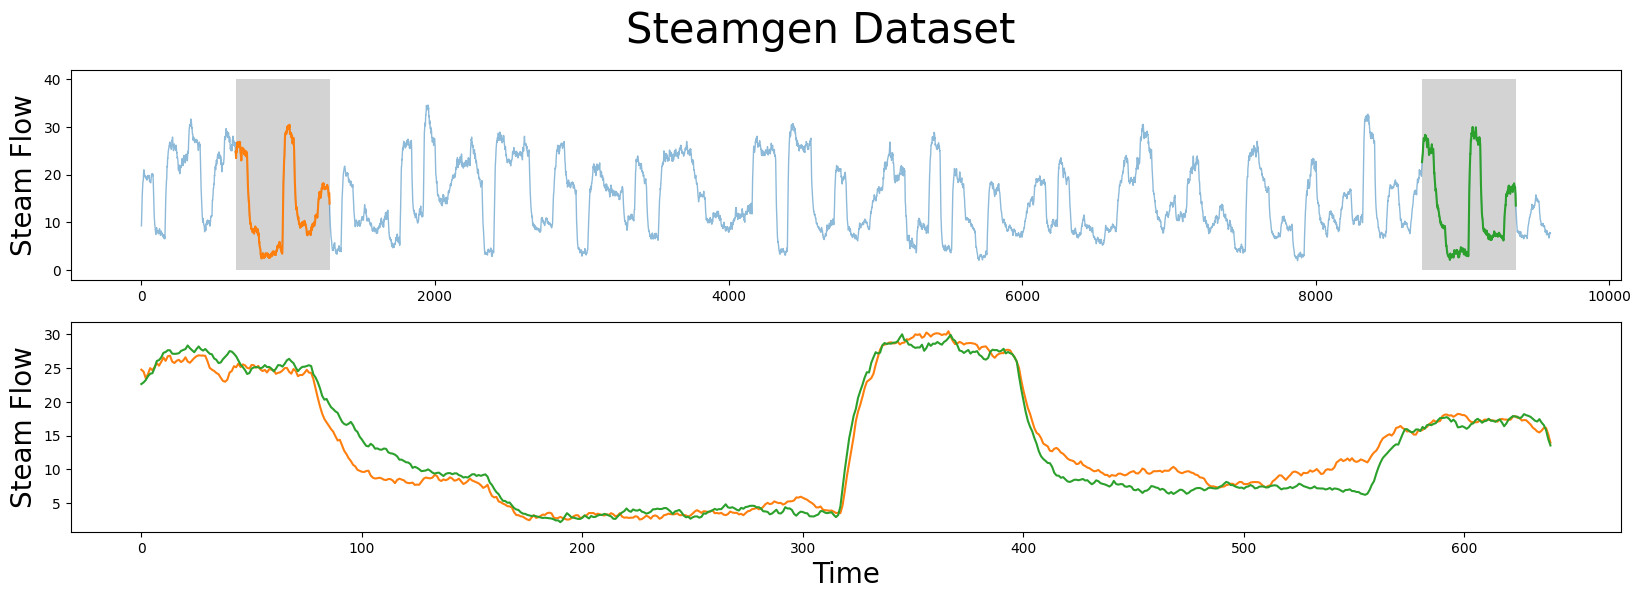

In [10]:
# Visualize with highlighted motif
m = 640
fig, axs = plt.subplots(2)
plt.suptitle('Steamgen Dataset', fontsize='30')
axs[0].set_ylabel("Steam Flow", fontsize='20')
axs[0].plot(steam_df['steam flow'], alpha=0.5, linewidth=1)
axs[0].plot(steam_df['steam flow'].iloc[643:643+m])
axs[0].plot(steam_df['steam flow'].iloc[8724:8724+m])
rect = Rectangle((643, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((8724, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[1].set_xlabel("Time", fontsize='20')
axs[1].set_ylabel("Steam Flow", fontsize='20')
axs[1].plot(steam_df['steam flow'].values[643:643+m], color='C1')
axs[1].plot(steam_df['steam flow'].values[8724:8724+m], color='C2')
plt.show()

In [11]:
# Compute Matrix Profile using STUMPY
m = 640
mp = stumpy.stump(steam_df['steam flow'], m)

In [12]:
# Find motif index (minimum matrix profile value)
motif_idx = np.argmin(mp[:, 0])
print(f"The motif is located at index {motif_idx}")

The motif is located at index 643


In [13]:
# Find nearest neighbor of the motif
nearest_neighbor_idx = int(mp[motif_idx, 1])
print(f"The nearest neighbor is located at index {nearest_neighbor_idx}")

The nearest neighbor is located at index 8724


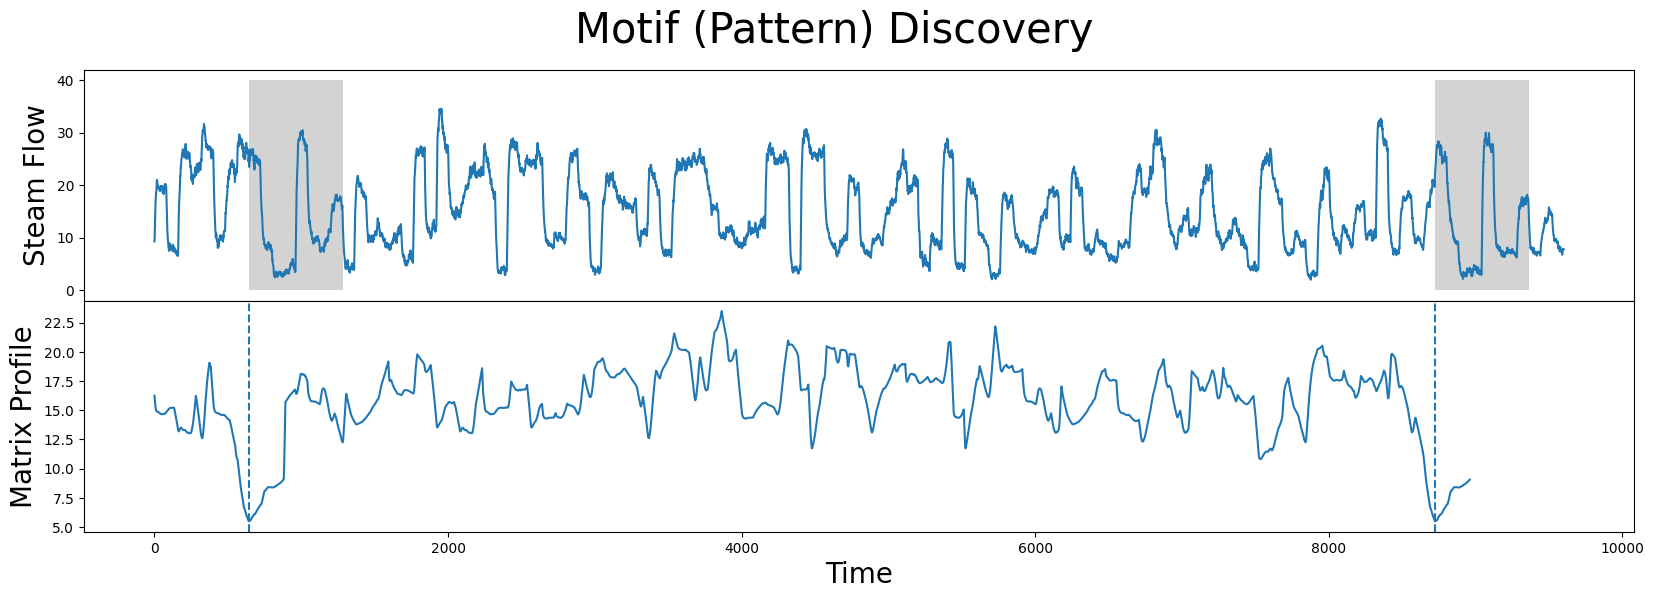

In [14]:
# Plot motif and matrix profile
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Motif (Pattern) Discovery', fontsize='30')

axs[0].plot(steam_df['steam flow'].values)
axs[0].set_ylabel('Steam Flow', fontsize='20')
rect = Rectangle((motif_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((nearest_neighbor_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=motif_idx, linestyle="dashed")
axs[1].axvline(x=nearest_neighbor_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])
plt.show()

In [15]:
# Print motif distance
print(f"Motif distance: {mp[motif_idx, 0]}")

Motif distance: 5.491619827769537


In [16]:
# Find discord index (maximum matrix profile value)
discord_idx = np.argmax(mp[:, 0])
print(f"The discord is located at index {discord_idx}")

The discord is located at index 3864


In [17]:
# Print discord distance
nearest_neighbor_distance = mp[discord_idx, 0]
print(f"The nearest neighbor subsequence to this discord is {nearest_neighbor_distance} units away")

The nearest neighbor subsequence to this discord is 23.476168367302016 units away


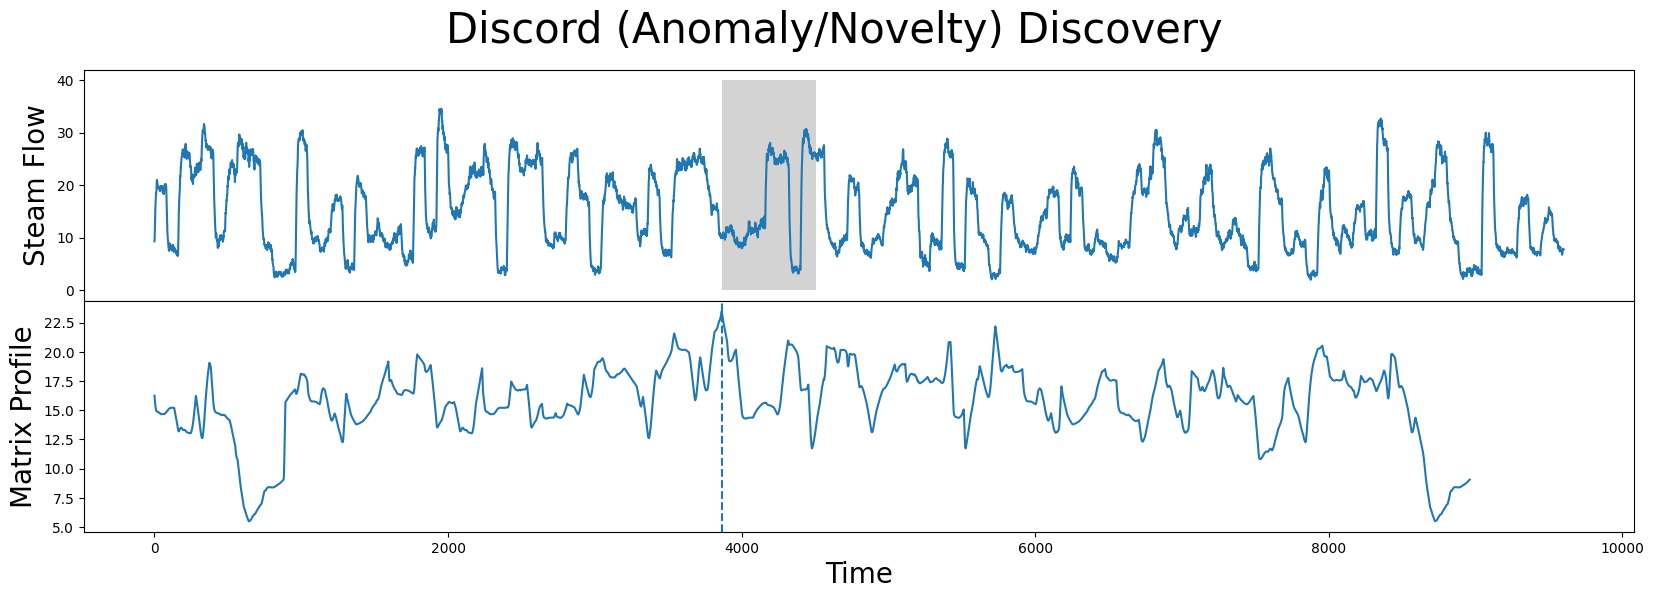

In [18]:
# Plot discord and matrix profile
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Discord (Anomaly/Novelty) Discovery', fontsize='30')

axs[0].plot(steam_df['steam flow'].values)
axs[0].set_ylabel('Steam Flow', fontsize='20')
rect = Rectangle((discord_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=discord_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])
plt.show()

# Example 2: NYC Taxi Passengers Dataset

In [19]:
# Read the taxi data
taxi_df = pd.read_csv('taxi_anomalies.csv')
taxi_df['value'] = taxi_df['value'].astype(np.float64)
taxi_df['timestamp'] = pd.to_datetime(taxi_df['timestamp'], errors='coerce')
taxi_df

/tmp/ipykernel_148/2737782773.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  taxi_df['timestamp'] = pd.to_datetime(taxi_df['timestamp'], errors='coerce')


,timestamp,value
0,2014-10-01 00:00:00,12751.0
1,2014-10-01 00:30:00,8767.0
2,2014-10-01 01:00:00,7005.0
3,2014-10-01 01:30:00,5257.0
4,2014-10-01 02:00:00,4189.0
...,...,...
3595,2014-12-14 21:30:00,16344.0
3596,2014-12-14 22:00:00,15913.0
3597,2014-12-14 22:30:00,14327.0
3598,2014-12-14 23:00:00,12060.0


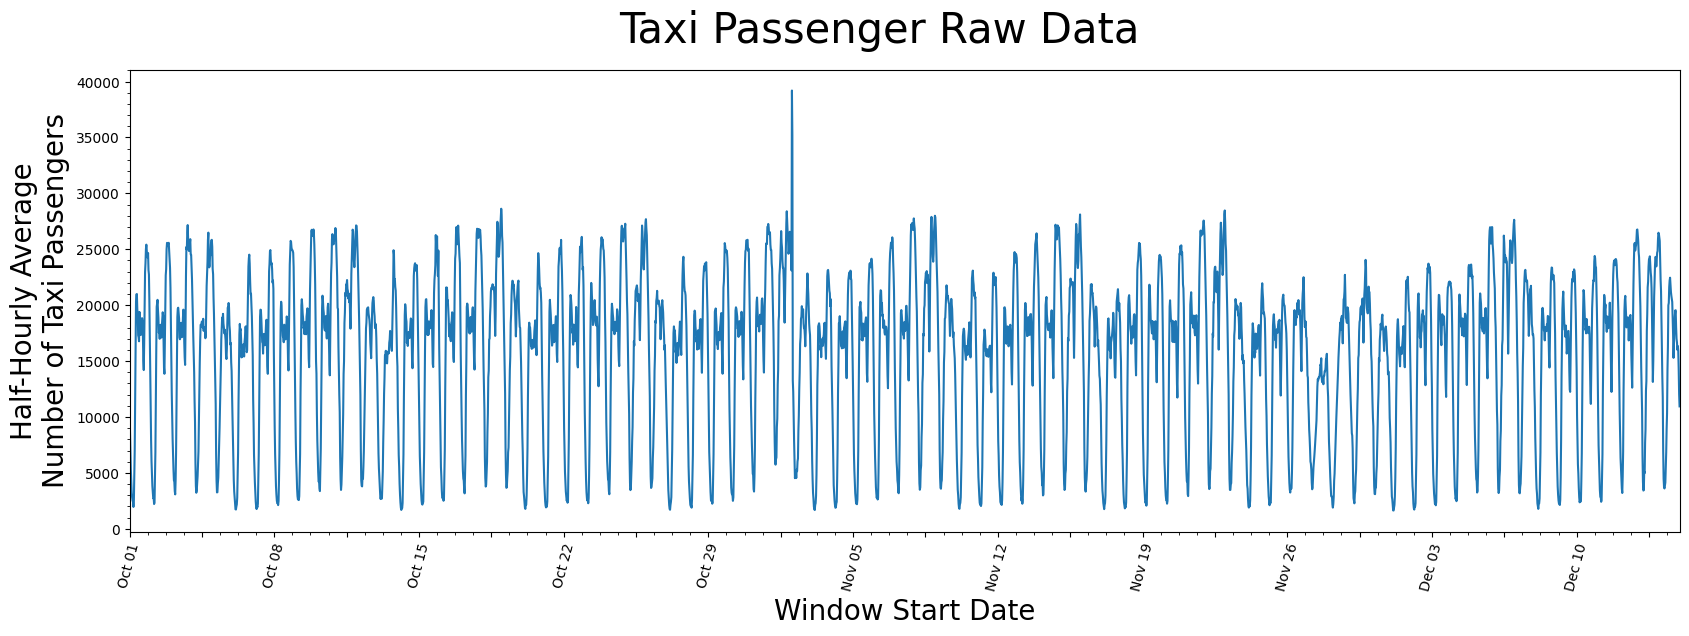

In [20]:
# Visualize taxi dataset with proper date labels
DAY_MULTIPLIER = 7  # Specify for the amount of days you want between each labeled x-axis tick

x_axis_labels = taxi_df[(taxi_df.timestamp.dt.hour==0)]['timestamp'].dt.strftime('%b %d').values[::DAY_MULTIPLIER]
x_axis_labels[1::2] = " "

plt.suptitle('Taxi Passenger Raw Data', fontsize='30')
plt.xlabel('Window Start Date', fontsize='20')
plt.ylabel('Half-Hourly Average\nNumber of Taxi Passengers', fontsize='20')
plt.plot(taxi_df['value'])

plt.xticks(np.arange(0, taxi_df['value'].shape[0], (48*DAY_MULTIPLIER)/2), x_axis_labels)
plt.xticks(rotation=75)
plt.minorticks_on()
plt.margins(x=0)
plt.show()

In [21]:
# Generate Matrix Profile for taxi data
m = 48
mp = stumpy.stump(taxi_df['value'], m)

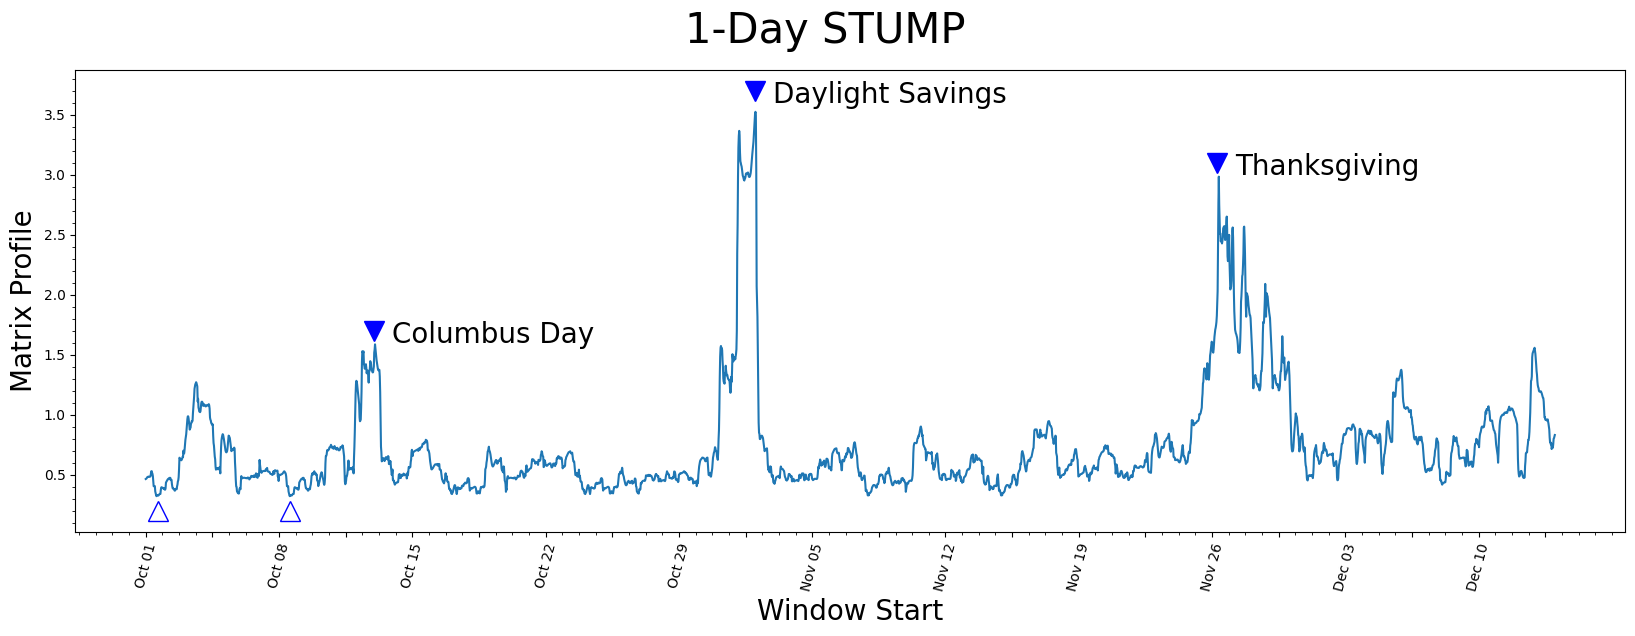

In [22]:
# Visualize Matrix Profile with annotations
plt.suptitle('1-Day STUMP', fontsize='30')
plt.xlabel('Window Start', fontsize='20')
plt.ylabel('Matrix Profile', fontsize='20')
plt.plot(mp[:, 0])

plt.plot(575, 1.7, marker="v", markersize=15, color='b')
plt.text(620, 1.6, 'Columbus Day', color="black", fontsize=20)
plt.plot(1535, 3.7, marker="v", markersize=15, color='b')
plt.text(1580, 3.6, 'Daylight Savings', color="black", fontsize=20)
plt.plot(2700, 3.1, marker="v", markersize=15, color='b')
plt.text(2745, 3.0, 'Thanksgiving', color="black", fontsize=20)
plt.plot(30, .2, marker="^", markersize=15, color='b', fillstyle='none')
plt.plot(363, .2, marker="^", markersize=15, color='b', fillstyle='none')
plt.xticks(np.arange(0, 3553, (m*DAY_MULTIPLIER)/2), x_axis_labels)
plt.xticks(rotation=75)
plt.minorticks_on()
plt.show()

In [23]:
# Create dictionary for different window sizes
days_dict ={
    "Half-Day": 24,
    "1-Day": 48,
    "2-Days": 96,
    "5-Days": 240,
    "7-Days": 336,
}

days_df = pd.DataFrame.from_dict(days_dict, orient='index', columns=['m'])
days_df.head()

,m
Half-Day,24
1-Day,48
2-Days,96
5-Days,240
7-Days,336


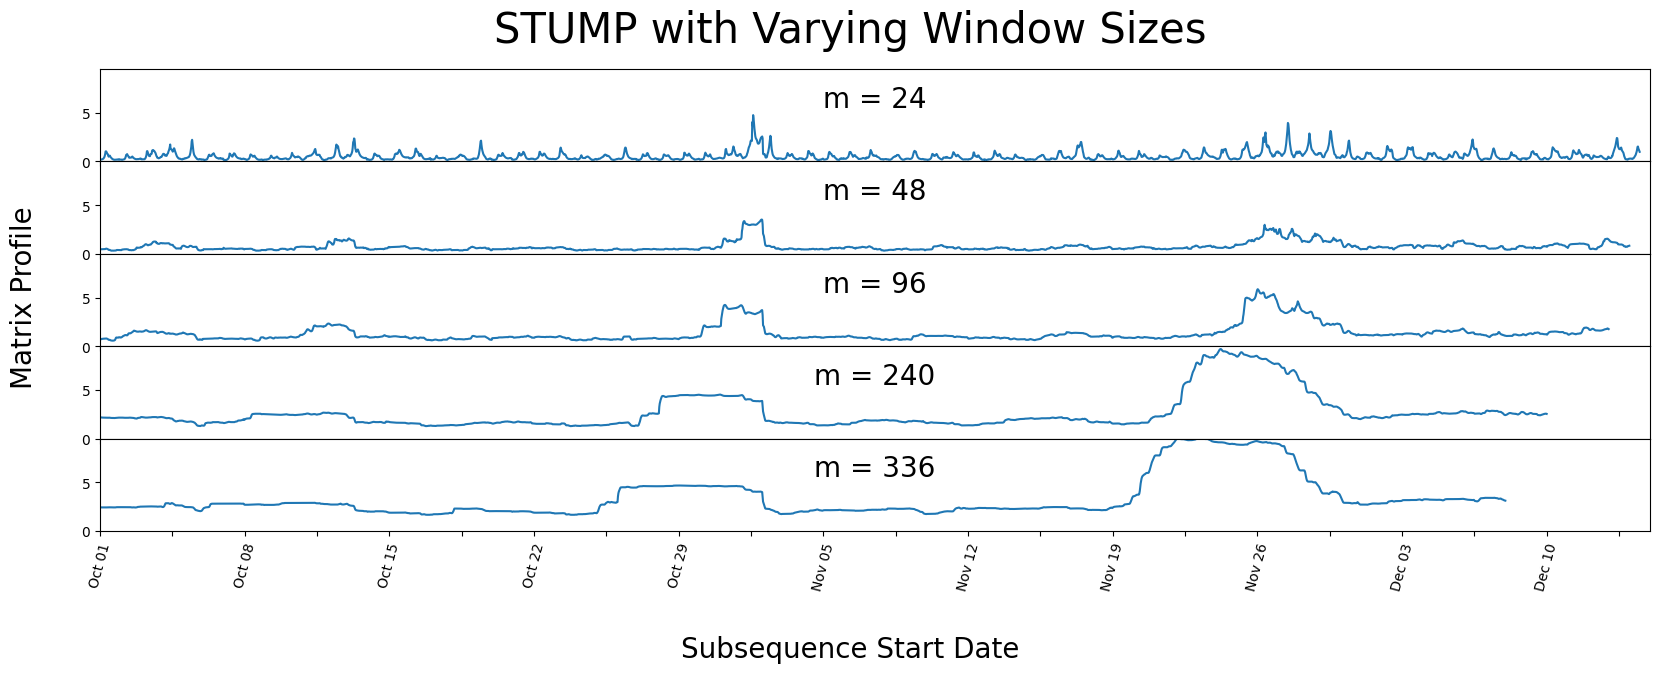

In [24]:
# Visualize Matrix Profile with varying window sizes
fig, axs = plt.subplots(5, sharex=True, gridspec_kw={'hspace': 0})
fig.text(0.5, -0.1, 'Subsequence Start Date', ha='center', fontsize='20')
fig.text(0.08, 0.5, 'Matrix Profile', va='center', rotation='vertical', fontsize='20')
for i, varying_m in enumerate(days_df['m'].values):
    mp_varying = stumpy.stump(taxi_df['value'], varying_m)
    axs[i].plot(mp_varying[:, 0])
    axs[i].set_ylim(0,9.5)
    axs[i].set_xlim(0,3600)
    title = f"m = {varying_m}"
    axs[i].set_title(title, fontsize=20, y=.5)
plt.xticks(np.arange(0, taxi_df.shape[0], (48*DAY_MULTIPLIER)/2), x_axis_labels)
plt.xticks(rotation=75)
plt.suptitle('STUMP with Varying Window Sizes', fontsize='30')
plt.show()

# Taxi Dataset Analysis

Taxi data motif at index: 27, date: 2014-10-01 13:30:00
Taxi data discord at index: 1537, date: 2014-11-02 00:30:00


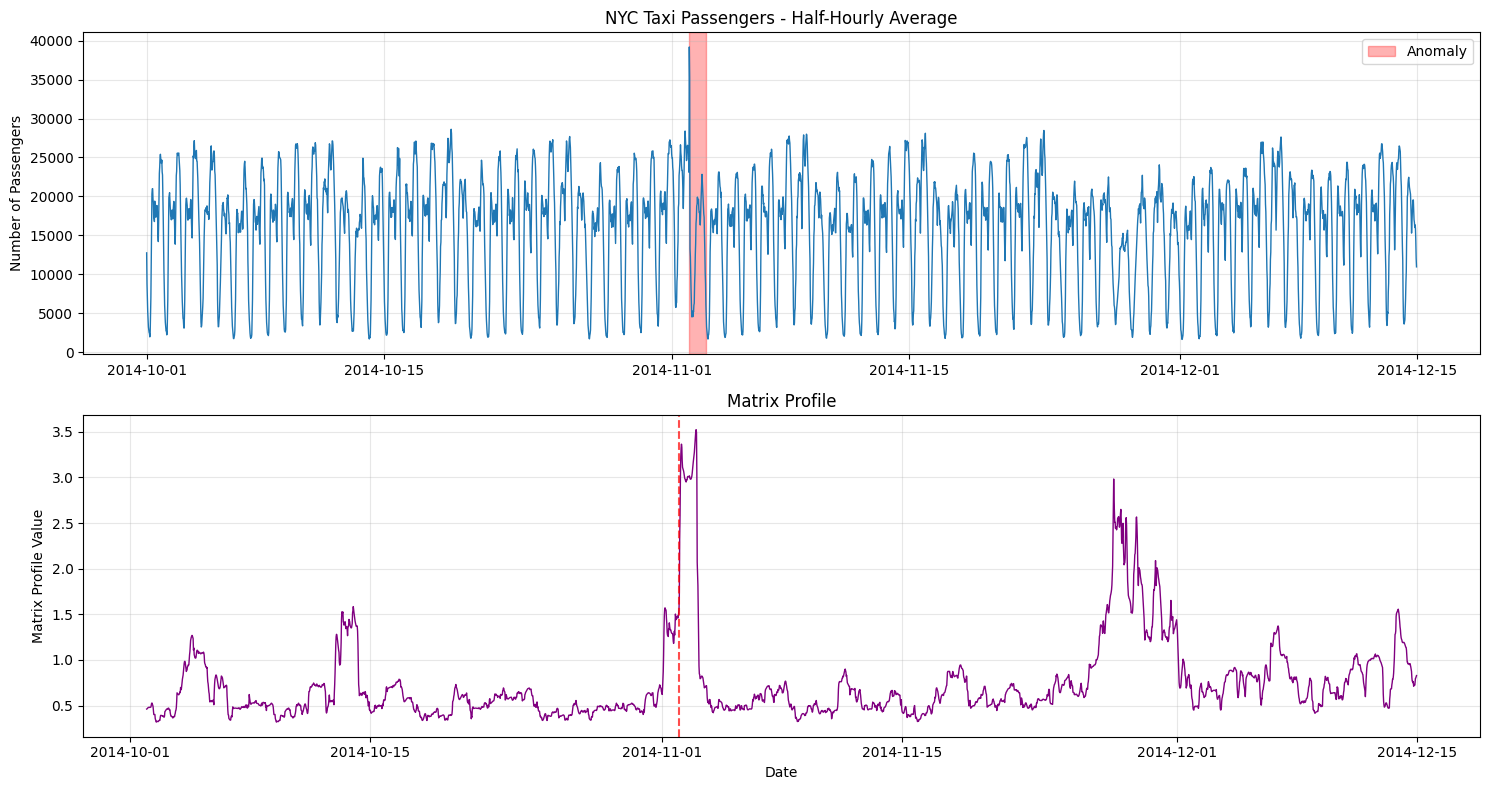

In [25]:
# Find motifs and discords in taxi data
motif_idx_taxi = np.argmin(mp[:, 0])
discord_idx_taxi = np.argmax(mp[:, 0])

print(f"Taxi data motif at index: {motif_idx_taxi}, date: {taxi_df['timestamp'].iloc[motif_idx_taxi]}")
print(f"Taxi data discord at index: {discord_idx_taxi}, date: {taxi_df['timestamp'].iloc[discord_idx_taxi]}")

# Visualize taxi data with anomaly highlighted
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(taxi_df['timestamp'], taxi_df['value'], linewidth=1)
plt.title('NYC Taxi Passengers - Half-Hourly Average')
plt.ylabel('Number of Passengers')

# Highlight anomaly region
plt.axvspan(taxi_df['timestamp'].iloc[discord_idx_taxi],
            taxi_df['timestamp'].iloc[discord_idx_taxi + m],
            color='red', alpha=0.3, label='Anomaly')

plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(taxi_df['timestamp'][m-1:], mp[:, 0], color='purple', linewidth=1)
plt.title('Matrix Profile')
plt.ylabel('Matrix Profile Value')
plt.xlabel('Date')
plt.axvline(x=taxi_df['timestamp'].iloc[discord_idx_taxi], color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hands-on Exercise: Stock Data Analysis

In [26]:
# Load dataset
df = pd.read_csv('stock_anomaly.csv')

# Display first rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Symbol,Open,High,Low,LTP,Chng,% Chng,Volume (lacs),Turnover (crs.),52w H,52w L,365 d % chng,30 d % chng
0,ADANIPORTS,750,766,713.25,715,-47.45,-6.22,72.20,532.63,901,384.4,79.22,-4.65
1,ASIANPAINT,"3,101.00","3,167.35","3,091.00","3,138.00",-6.25,-0.20,10.29,322.53,"3,505.00","2,117.15",45.66,5.66
2,AXISBANK,669,674.9,660.45,661,-18.90,-2.78,102.53,684,866.9,568.4,10.19,-21.49
3,BAJAJ-AUTO,"3,370.00","3,383.50","3,320.00","3,335.00",-56.70,-1.67,3.42,114.59,"4,361.40","3,041.00",9.30,-12.05
4,BAJAJFINSV,"17,200.00","17,237.20","16,610.00","16,684.00",-684.85,-3.94,3.42,576.79,"19,325.00","8,273.70",91.38,-9.10


In [27]:
# List unique companies (tickers)
tickers = df['Symbol'].unique()

# Show how many and which companies
print(f"Number of companies in dataset: {len(tickers)}")
print("\nList of companies (tickers):")
print(", ".join(tickers[:10]))  # Show first 10
print("...")

Number of companies in dataset: 50

List of companies (tickers):
ADANIPORTS, ASIANPAINT, AXISBANK, BAJAJ-AUTO, BAJAJFINSV, BAJFINANCE, BHARTIARTL, BPCL, BRITANNIA, CIPLA
...


```
1. Select a company to analyze

In [28]:
# Select a company (e.g., 'TATAMOTORS')
company_name = 'TATAMOTORS'

# Filter data for that company
company_df = df[df['Symbol'] == company_name].copy()

# Clean and convert numeric columns
# Remove commas and convert to float for columns with comma formatting
for col in ['Open', 'High', 'Low', 'LTP']:
    if col in company_df.columns:
        company_df[col] = company_df[col].astype(str).str.replace(',', '').astype(float)

# Show rows to check data
print(f"Data for {company_name}:")
company_df

Data for TATAMOTORS:


,Symbol,Open,High,Low,LTP,Chng,% Chng,Volume (lacs),Turnover (crs.),52w H,52w L,365 d % chng,30 d % chng
42,TATAMOTORS,486.0,486.75,458.0,459.4,-33.35,-6.77,517.88,"2,430.36",536.7,156.7,167.95,-9.68


```
2. Plot 'Close' price (LTP) over time


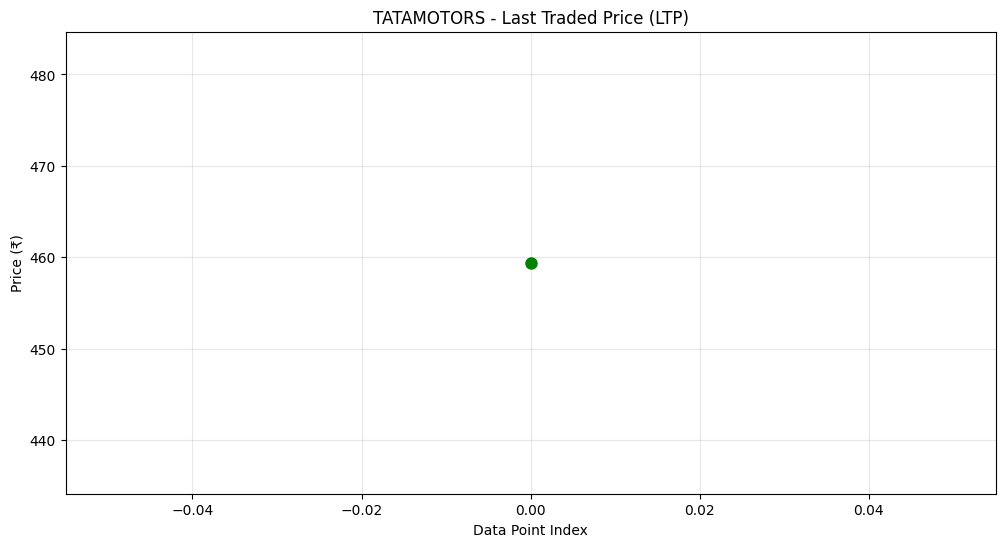

In [29]:
# Since we don't have a date column, we'll create a simple index
company_df['Index'] = range(len(company_df))

plt.figure(figsize=(12, 6))
plt.plot(company_df['Index'], company_df['LTP'], marker='o', linestyle='-', color='green', markersize=8)
plt.title(f'{company_name} - Last Traded Price (LTP)')
plt.xlabel('Data Point Index')
plt.ylabel('Price (₹)')
plt.grid(True, alpha=0.3)
plt.show()

```
3. Compute the Matrix Profile on 'LTP' price

### Loading Time Series Stock Data

For meaningful time series analysis, your dataset should contain multiple data points over time for the stock you wish to analyze. Below is an example of how to load a CSV file containing historical stock prices, ensuring the date column is correctly parsed and set as the DataFrame index.

In [33]:
import pandas as pd

# Assuming you have a CSV file with historical stock data, e.g., 'stock_historical.csv'
# It should have at least 'Date' and 'Close' price columns.
# For demonstration, let's create a dummy DataFrame first.

# Create dummy data for demonstration
dummy_data = {
    'Date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07']),
    'Close': [100.0, 101.5, 102.3, 100.8, 103.1, 104.5, 103.9]
}
df_stock_ts = pd.DataFrame(dummy_data)

# In a real scenario, you would load from a CSV like this:
# df_stock_ts = pd.read_csv('stock_historical.csv')

# Ensure the 'Date' column is in datetime format
df_stock_ts['Date'] = pd.to_datetime(df_stock_ts['Date'])

# Set 'Date' as the index for time series analysis
df_stock_ts = df_stock_ts.set_index('Date')

print("Loaded Stock Time Series Data:")
display(df_stock_ts.head())
print(f"Data shape: {df_stock_ts.shape}")

Loaded Stock Time Series Data:


,Close
Date,
2023-01-01,100.0
2023-01-02,101.5
2023-01-03,102.3
2023-01-04,100.8
2023-01-05,103.1


Data shape: (7, 1)


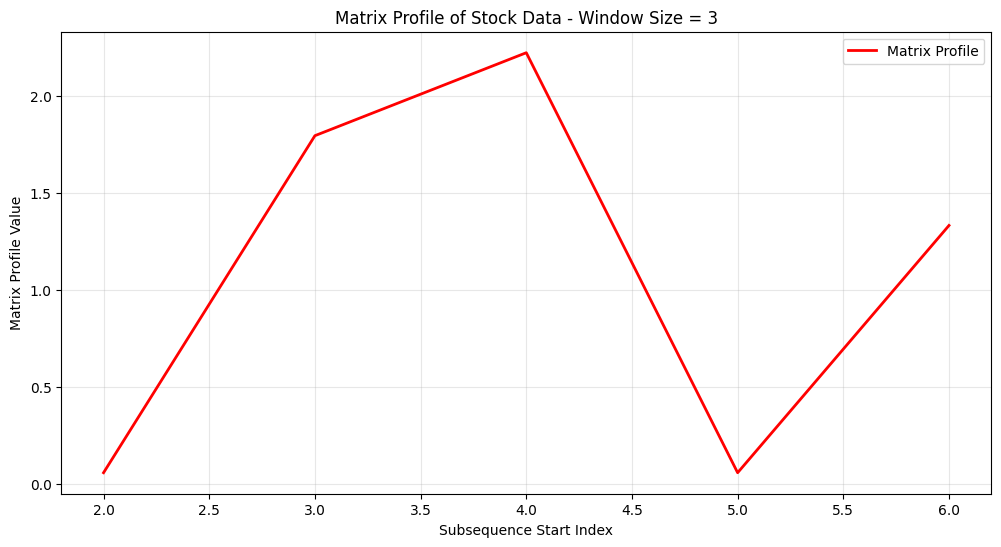

Matrix Profile computed with window size = 3


In [34]:
# Define window size (subsequence length)
window_size = 3  # A suitable window size for a time series of length 7

# Get the price series from the newly loaded time series data
price_series = df_stock_ts['Close'].values

# Compute Matrix Profile
mp = stumpy.stump(price_series, m=window_size)
matrix_profile = mp[:, 0]

# Plot Matrix Profile
plt.figure(figsize=(12, 6))
plt.plot(range(window_size-1, len(price_series)), matrix_profile, color='red', linewidth=2, label='Matrix Profile')
plt.title(f'Matrix Profile of Stock Data - Window Size = {window_size}')
plt.xlabel('Subsequence Start Index')
plt.ylabel('Matrix Profile Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Matrix Profile computed with window size = {window_size}")

```
4. Detect the most unusual subsequence (Discord) and highlight it

Most unusual pattern (discord) for TATAMOTORS starts at index: 2
Discord value: 2.2251


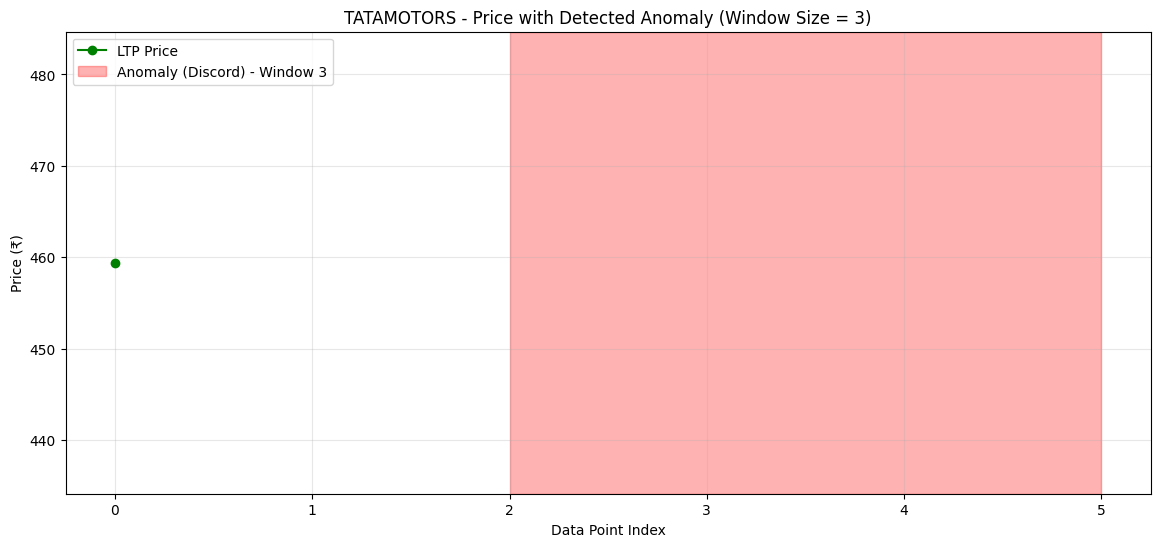


Anomalous subsequence values: [102.3 100.8 103.1]


In [35]:
# Find discord index (highest Matrix Profile value)
discord_idx = matrix_profile.argmax()
print(f"Most unusual pattern (discord) for {company_name} starts at index: {discord_idx}")
print(f"Discord value: {matrix_profile[discord_idx]:.4f}")

# Plot with discord highlighted
plt.figure(figsize=(14, 6))

# Plot the price series
plt.plot(company_df['Index'], company_df['LTP'], marker='o', linestyle='-',
         color='green', markersize=6, linewidth=1.5, label='LTP Price')

# Highlight the anomaly region
plt.axvspan(discord_idx, discord_idx + window_size,
            color='red', alpha=0.3, label=f'Anomaly (Discord) - Window {window_size}')

plt.title(f'{company_name} - Price with Detected Anomaly (Window Size = {window_size})')
plt.xlabel('Data Point Index')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Show the actual anomalous subsequence
anomaly_sequence = price_series[discord_idx:discord_idx + window_size]
print(f"\nAnomalous subsequence values: {anomaly_sequence}")

```
5. Ddifferent companies and window sizes

In [36]:
# Function to analyze any company
def analyze_company(ticker, window_size=5):
    """Analyze a company's stock for anomalies using Matrix Profile"""

    # Get company data
    comp_data = df[df['Symbol'] == ticker].copy()

    # Clean numeric columns
    for col in ['Open', 'High', 'Low', 'LTP']:
        if col in comp_data.columns:
            comp_data[col] = comp_data[col].astype(str).str.replace(',', '').astype(float)

    price = comp_data['LTP'].values

    # Compute Matrix Profile
    mp = stumpy.stump(price, m=window_size)
    matrix_profile = mp[:, 0]

    # Find discord
    discord_idx = matrix_profile.argmax()

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Price plot
    ax1.plot(range(len(price)), price, color='green', linewidth=1.5, label='Price')
    ax1.axvspan(discord_idx, discord_idx + window_size, color='red', alpha=0.3, label='Anomaly')
    ax1.set_ylabel('Price (₹)')
    ax1.set_title(f'{ticker} - Stock Price with Detected Anomaly (Window={window_size})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Matrix Profile plot
    ax2.plot(range(window_size-1, len(price)), matrix_profile, color='purple', linewidth=1.5)
    ax2.axvline(x=discord_idx, color='red', linestyle='--', alpha=0.7, label=f'Discord at index {discord_idx}')
    ax2.set_xlabel('Data Point Index')
    ax2.set_ylabel('Matrix Profile Value')
    ax2.set_title('Matrix Profile')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return discord_idx, matrix_profile[discord_idx]

# Try different companies
companies_to_try = ['RELIANCE', 'TCS', 'HDFCBANK', 'TATASTEEL']

for company in companies_to_try:
    print(f"\n{'='*50}")
    print(f"Analyzing {company}...")
    try:
        idx, val = analyze_company(company, window_size=7)
        print(f"Discord at index {idx} with value {val:.4f}")
    except Exception as e:
        print(f"Error analyzing {company}: {e}")


Analyzing RELIANCE...
Error analyzing RELIANCE: The window size must be less than or equal to 1

Analyzing TCS...
Error analyzing TCS: The window size must be less than or equal to 1

Analyzing HDFCBANK...
Error analyzing HDFCBANK: The window size must be less than or equal to 1

Analyzing TATASTEEL...
Error analyzing TATASTEEL: The window size must be less than or equal to 1


```
6. Create a market index by aggregating across companies

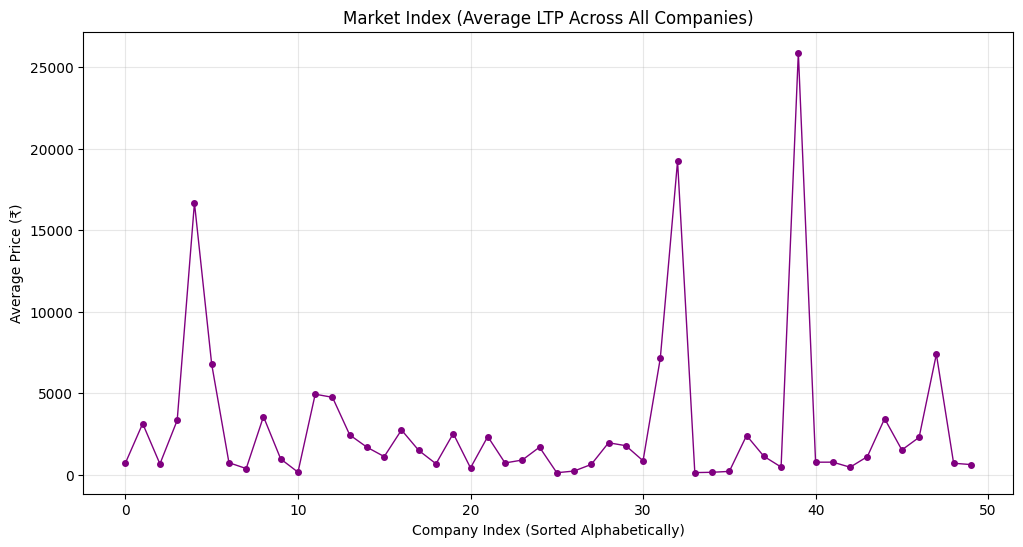

Market index created with 50 data points


In [37]:
# Clean all numeric columns for all companies
df_clean = df.copy()

# Function to clean currency columns
def clean_currency(val):
    if isinstance(val, str):
        return float(val.replace(',', ''))
    return float(val)

# Clean all relevant columns
for col in ['Open', 'High', 'Low', 'LTP']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_currency)

# Create market index (average LTP across all companies per data point)
# Note: Since each company only has one row, we're creating a pseudo time series
# In reality, you would have daily data for each company

# For demonstration, we'll create a synthetic time series by using each company as a "time point"
market_index = df_clean['LTP'].values

plt.figure(figsize=(12, 6))
plt.plot(range(len(market_index)), market_index, marker='o', linestyle='-',
         color='purple', markersize=4, linewidth=1)
plt.title('Market Index (Average LTP Across All Companies)')
plt.xlabel('Company Index (Sorted Alphabetically)')
plt.ylabel('Average Price (₹)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Market index created with {len(market_index)} data points")

```
7. Compute Matrix Profile on the Market Index

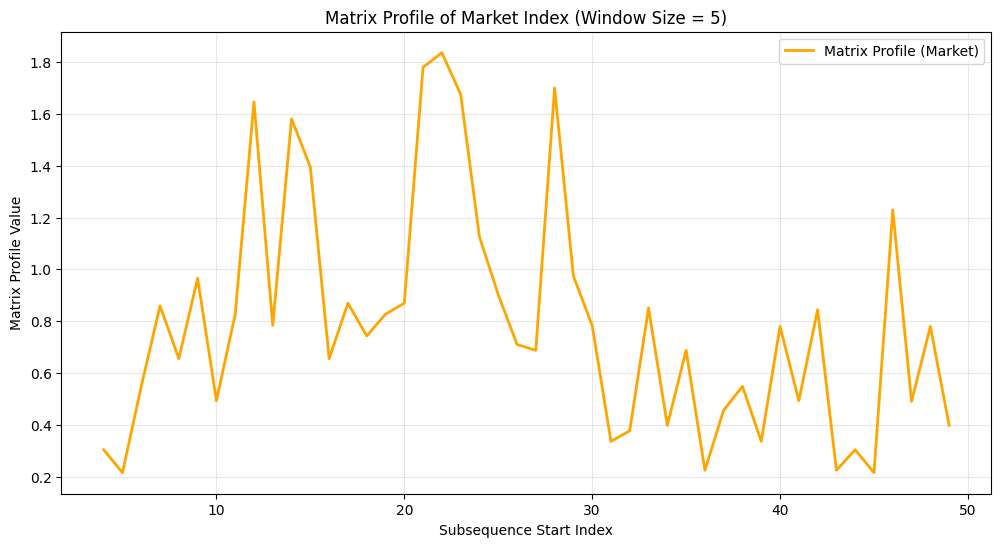

In [38]:
# Window size for market-level pattern detection
market_window_size = 5

# Compute Matrix Profile
market_mp = stumpy.stump(market_index, m=market_window_size)
market_matrix_profile = market_mp[:, 0]

# Plot Matrix Profile
plt.figure(figsize=(12, 6))
plt.plot(range(market_window_size-1, len(market_index)), market_matrix_profile,
         color='orange', linewidth=2, label='Matrix Profile (Market)')
plt.title(f'Matrix Profile of Market Index (Window Size = {market_window_size})')
plt.xlabel('Subsequence Start Index')
plt.ylabel('Matrix Profile Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

```
8. Detect Market Discord (Anomaly)

Market anomaly starts at index: 18
Market anomaly value: 1.8357


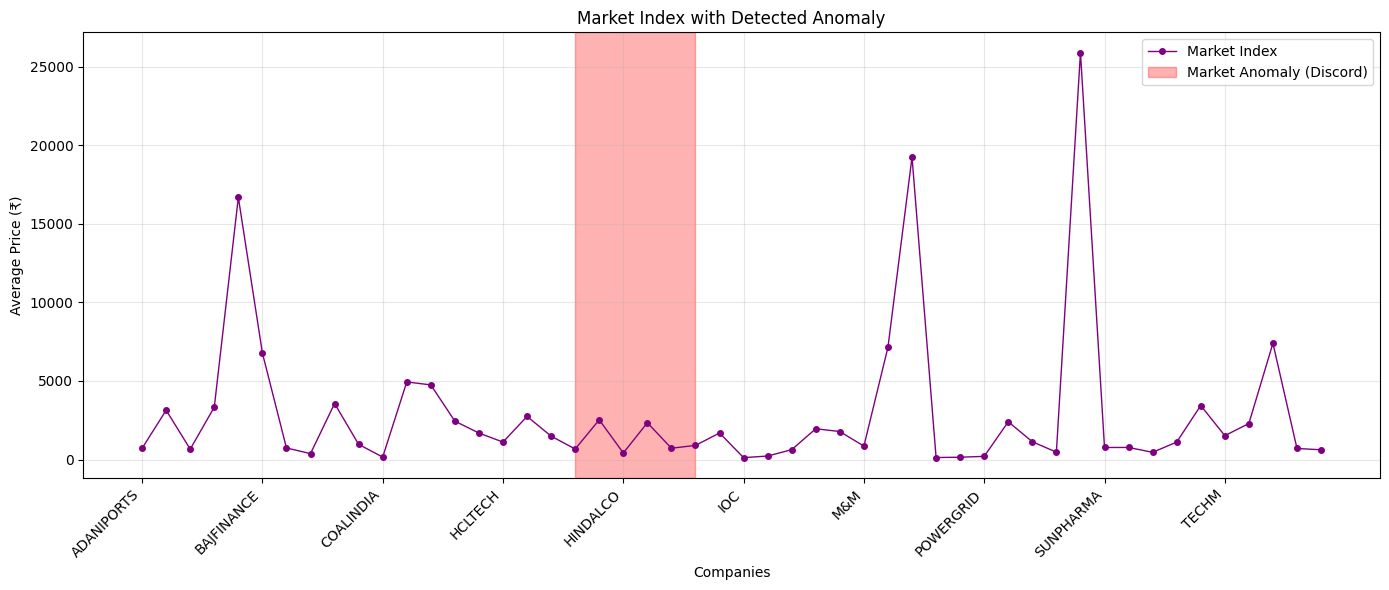


Companies in the anomalous region:
  1. HDFCLIFE
  2. HEROMOTOCO
  3. HINDALCO
  4. HINDUNILVR
  5. ICICIBANK


In [39]:
# Find discord
market_discord_idx = market_matrix_profile.argmax()
print(f"Market anomaly starts at index: {market_discord_idx}")
print(f"Market anomaly value: {market_matrix_profile[market_discord_idx]:.4f}")

# Plot anomaly
plt.figure(figsize=(14, 6))

# Plot market index
plt.plot(range(len(market_index)), market_index, marker='o', linestyle='-',
         color='purple', markersize=4, linewidth=1, label='Market Index')

# Highlight anomaly
plt.axvspan(market_discord_idx, market_discord_idx + market_window_size,
            color='red', alpha=0.3, label=f'Market Anomaly (Discord)')

# Add company names as x-tick labels for better context
company_names = df_clean['Symbol'].values
plt.xticks(range(0, len(market_index), 5), company_names[::5], rotation=45, ha='right')

plt.title('Market Index with Detected Anomaly')
plt.xlabel('Companies')
plt.ylabel('Average Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show which companies are in the anomalous region
anomaly_companies = company_names[market_discord_idx:market_discord_idx + market_window_size]
print(f"\nCompanies in the anomalous region:")
for i, company in enumerate(anomaly_companies):
    print(f"  {i+1}. {company}")

```
9. Detect Market Motif (Most Repeated Pattern)

Market motif starts at index: 1
Market motif value: 0.2155
Nearest neighbor of motif at index: 41


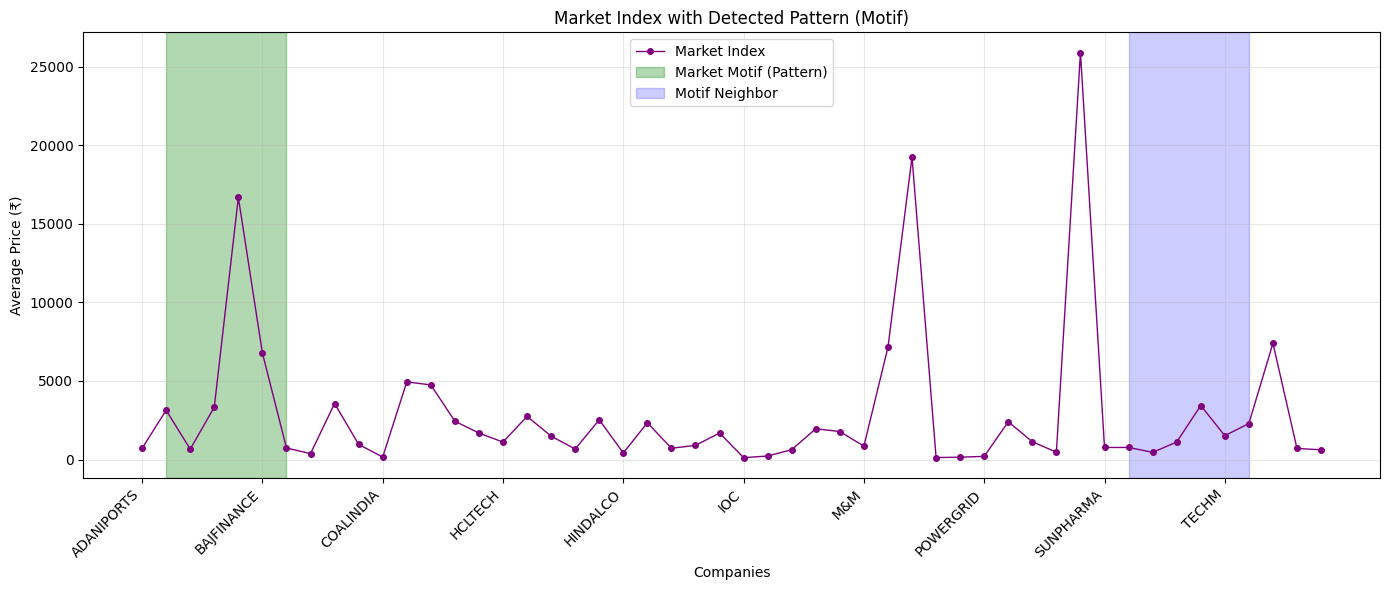


Motif pattern (companies 1-5):
  ASIANPAINT: ₹3138.00
  AXISBANK: ₹661.00
  BAJAJ-AUTO: ₹3335.00
  BAJAJFINSV: ₹16684.00
  BAJFINANCE: ₹6780.00

Nearest neighbor pattern (companies 41-45):
  TATACONSUM: ₹769.90
  TATAMOTORS: ₹459.40
  TATASTEEL: ₹1110.25
  TCS: ₹3439.20
  TECHM: ₹1519.00


In [40]:
# Find motif (minimum Matrix Profile value)
market_motif_idx = market_matrix_profile.argmin()
print(f"Market motif starts at index: {market_motif_idx}")
print(f"Market motif value: {market_matrix_profile[market_motif_idx]:.4f}")

# Find the nearest neighbor of this motif
motif_neighbor_idx = int(market_mp[market_motif_idx, 1])
print(f"Nearest neighbor of motif at index: {motif_neighbor_idx}")

# Plot motif
plt.figure(figsize=(14, 6))

# Plot market index
plt.plot(range(len(market_index)), market_index, marker='o', linestyle='-',
         color='purple', markersize=4, linewidth=1, label='Market Index')

# Highlight motif
plt.axvspan(market_motif_idx, market_motif_idx + market_window_size,
            color='green', alpha=0.3, label=f'Market Motif (Pattern)')

# Highlight motif's neighbor
plt.axvspan(motif_neighbor_idx, motif_neighbor_idx + market_window_size,
            color='blue', alpha=0.2, label=f'Motif Neighbor')

# Add company names as x-tick labels
plt.xticks(range(0, len(market_index), 5), company_names[::5], rotation=45, ha='right')

plt.title('Market Index with Detected Pattern (Motif)')
plt.xlabel('Companies')
plt.ylabel('Average Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show the motif and its neighbor
motif_companies = company_names[market_motif_idx:market_motif_idx + market_window_size]
neighbor_companies = company_names[motif_neighbor_idx:motif_neighbor_idx + market_window_size]

print(f"\nMotif pattern (companies {market_motif_idx}-{market_motif_idx + market_window_size-1}):")
for i, company in enumerate(motif_companies):
    price = market_index[market_motif_idx + i]
    print(f"  {company}: ₹{price:.2f}")

print(f"\nNearest neighbor pattern (companies {motif_neighbor_idx}-{motif_neighbor_idx + market_window_size-1}):")
for i, company in enumerate(neighbor_companies):
    price = market_index[motif_neighbor_idx + i]
    print(f"  {company}: ₹{price:.2f}")

```
10. Comprehensive Analysis Function

In [44]:
def comprehensive_stock_analysis(ticker, window_size=5):
    """
    Comprehensive analysis of a stock using Matrix Profile
    """
    print(f"\n{'='*60}")
    print(f"COMPREHENSIVE ANALYSIS FOR: {ticker}")
    print('='*60)

    # Get data
    comp_data = df_clean[df_clean['Symbol'] == ticker].copy()

    if len(comp_data) == 0:
        print(f"No data found for {ticker}")
        return

    price = comp_data['LTP'].values

    # Statistics
    print(f"\n Stock Statistics:")
    print(f"  Current Price: ₹{price[0]:.2f}")
    print(f"  52-Week High: ₹{comp_data['52w H'].values[0]:.2f}")
    print(f"  52-Week Low: ₹{comp_data['52w L'].values[0]:.2f}")
    print(f"  365-Day Change: {comp_data['365 d % chng'].values[0]}%")
    print(f"  30-Day Change: {comp_data['30 d % chng'].values[0]}%")

    # Matrix Profile
    # Ensure price series has enough data for the window size
    if len(price) < window_size:
        print(f"Error: Not enough data points ({len(price)}) for window size ({window_size}). Skipping Matrix Profile.")
        return

    mp = stumpy.stump(price, m=window_size)
    matrix_profile = mp[:, 0]

    # Find motif and discord
    discord_idx = matrix_profile.argmax()
    motif_idx = matrix_profile.argmin()

    print(f"\n Matrix Profile Analysis (Window Size = {window_size}):")
    print(f"  Discord (Anomaly) at index {discord_idx}, value: {matrix_profile[discord_idx]:.4f}")
    print(f"  Motif (Pattern) at index {motif_idx}, value: {matrix_profile[motif_idx]:.4f}")

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Price plot with anomaly
    axes[0].plot(range(len(price)), price, 'o-', color='green', markersize=6, linewidth=1.5)
    axes[0].axvspan(discord_idx, discord_idx + window_size, color='red', alpha=0.3, label='Anomaly')
    axes[0].set_ylabel('Price (₹)')
    axes[0].set_title(f'{ticker} - Stock Price')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Matrix Profile
    axes[1].plot(range(window_size-1, len(price)), matrix_profile, color='purple', linewidth=1.5)
    axes[1].axvline(x=discord_idx, color='red', linestyle='--', alpha=0.7, label=f'Discord')
    axes[1].axvline(x=motif_idx, color='green', linestyle='--', alpha=0.7, label=f'Motif')
    axes[1].set_ylabel('Matrix Profile')
    axes[1].set_title('Matrix Profile')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Highlighted subsequences
    axes[2].plot(range(window_size), price[discord_idx:discord_idx + window_size],
                 'o-', color='red', linewidth=2, markersize=8, label='Anomaly')
    axes[2].plot(range(window_size), price[motif_idx:motif_idx + window_size],
                 'o-', color='green', linewidth=2, markersize=8, label='Motif')
    axes[2].set_xlabel('Point in Subsequence')
    axes[2].set_ylabel('Price (₹)')
    axes[2].set_title('Anomaly vs Motif Subsequences')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run comprehensive analysis for a few companies
# Re-run the cleaning step for df_clean to include '52w H' and '52w L' if not already done
# Clean all numeric columns for all companies
df_clean = df.copy()

# Function to clean currency columns
def clean_currency(val):
    if isinstance(val, str):
        return float(val.replace(',', ''))
    return float(val)

# Clean all relevant columns, including 52w H and 52w L
for col in ['Open', 'High', 'Low', 'LTP', '52w H', '52w L']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_currency)

for ticker in ['TATAMOTORS', 'RELIANCE', 'HDFCBANK', 'INFY']:
    comprehensive_stock_analysis(ticker, window_size=5)



COMPREHENSIVE ANALYSIS FOR: TATAMOTORS

 Stock Statistics:
  Current Price: ₹459.40
  52-Week High: ₹536.70
  52-Week Low: ₹156.70
  365-Day Change: 167.95%
  30-Day Change: -9.68%
Error: Not enough data points (1) for window size (5). Skipping Matrix Profile.

COMPREHENSIVE ANALYSIS FOR: RELIANCE

 Stock Statistics:
  Current Price: ₹2405.10
  52-Week High: ₹2751.35
  52-Week Low: ₹1830.00
  365-Day Change: 23.48%
  30-Day Change: -9.62%
Error: Not enough data points (1) for window size (5). Skipping Matrix Profile.

COMPREHENSIVE ANALYSIS FOR: HDFCBANK

 Stock Statistics:
  Current Price: ₹1489.50
  52-Week High: ₹1725.00
  52-Week Low: ₹1342.00
  365-Day Change: 6.18%
  30-Day Change: -9.88%
Error: Not enough data points (1) for window size (5). Skipping Matrix Profile.

COMPREHENSIVE ANALYSIS FOR: INFY

 Stock Statistics:
  Current Price: ₹1689.55
  52-Week High: ₹1848.00
  52-Week Low: ₹1091.00
  365-Day Change: 51.44%
  30-Day Change: -0.83%
Error: Not enough data points (1) for

### Summary Statistics

In [46]:
# Summary statistics for all companies
print(" MARKET SUMMARY STATISTICS")
print("="*50)

print(f"\nTotal Companies: {len(df_clean)}")

# Price statistics
print(f"\nPrice Statistics (LTP):")
print(f"  Average Price: ₹{df_clean['LTP'].mean():.2f}")
print(f"  Median Price: ₹{df_clean['LTP'].median():.2f}")
print(f"  Min Price: ₹{df_clean['LTP'].min():.2f} ({df_clean.loc[df_clean['LTP'].idxmin(), 'Symbol']})")
print(f"  Max Price: ₹{df_clean['LTP'].max():.2f} ({df_clean.loc[df_clean['LTP'].idxmax(), 'Symbol']})")

# Top gainers and losers
print(f"\n Top 5 Gainers (365-day):")
top_gainers = df_clean.nlargest(5, '365 d % chng')[['Symbol', '365 d % chng']]
for _, row in top_gainers.iterrows():
    print(f"  {row['Symbol']}: {row['365 d % chng']}%")

print(f"\n Top 5 Losers (365-day):")
top_losers = df_clean.nsmallest(5, '365 d % chng')[['Symbol', '365 d % chng']]
for _, row in top_losers.iterrows():
    print(f"  {row['Symbol']}: {row['365 d % chng']}%")

 MARKET SUMMARY STATISTICS

Total Companies: 50

Price Statistics (LTP):
  Average Price: ₹2939.57
  Median Price: ₹1121.25
  Min Price: ₹121.15 (IOC)
  Max Price: ₹25900.00 (SHREECEM)

 Top 5 Gainers (365-day):
  TATAMOTORS: 167.95%
  TATASTEEL: 105.13%
  GRASIM: 99.95%
  SBIN: 93.42%
  BAJAJFINSV: 91.38%

 Top 5 Losers (365-day):
  HEROMOTOCO: -16.02%
  EICHERMOT: -5.95%
  BPCL: -1.22%
  DRREDDY: -1.17%
  BRITANNIA: 0.3%
